In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

from pymargins import Margins

rng = np.random.default_rng(42)
n = 2000
df = pd.DataFrame(
    {
        "age": rng.integers(20, 75, n),
        "female": rng.binomial(1, 0.52, n),
        "treated": rng.binomial(1, 0.40, n),
        "region": rng.choice(["N", "S", "E", "W"], n),
    }
)
lp = (
    -1.5
    + 0.04 * df["age"]
    - 0.3 * df["female"]
    + 0.8 * df["treated"]
    + 0.2 * (df["region"] == "S")
    + 0.4 * (df["region"] == "E")
    - 0.1 * (df["region"] == "W")
)
df["y"] = rng.binomial(1, 1 / (1 + np.exp(-lp)))

fit = smf.glm(
    "y ~ age + female + treated + C(region)", data=df, family=sm.families.Binomial()
).fit()
m = Margins.log_scale(fit, at="overall")

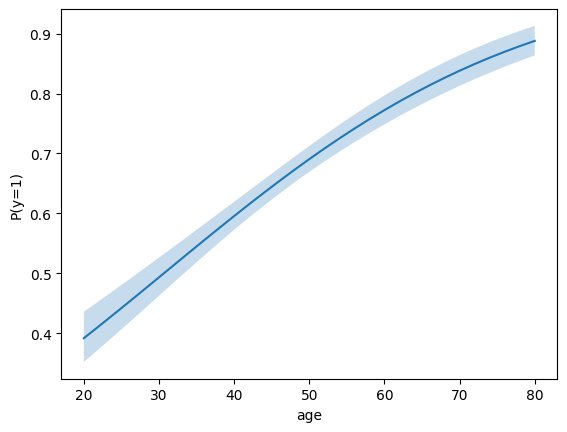

In [2]:
import matplotlib.pyplot as plt

ages = list(range(20, 81, 2))
res = m.predict(atexog={"age": ages})
df = res.to_frame()

fig, ax = plt.subplots()
ax.plot(df["age"], df["estimate"])
ax.fill_between(df["age"], df["ci_lower"], df["ci_upper"], alpha=0.25)
ax.set(xlabel="age", ylabel="P(y=1)");

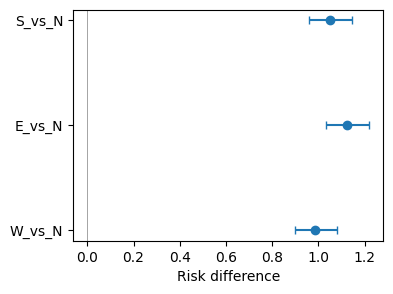

In [3]:
from pymargins import reference

scen, W = reference("region", ["N", "S", "E", "W"], ref_level="N")
res = m.contrasts(scenarios=scen, contrasts=W)
df = res.to_frame()

fig, ax = plt.subplots(figsize=(4, 3))
y = range(len(df))
ax.errorbar(
    df["estimate"],
    y,
    xerr=[df["estimate"] - df["ci_lower"], df["ci_upper"] - df["estimate"]],
    fmt="o",
    capsize=3,
)
ax.axvline(0, color="grey", lw=0.5)
ax.set_yticks(list(y))
ax.set_yticklabels(df["label"])
ax.set_xlabel("Risk difference")
ax.invert_yaxis()

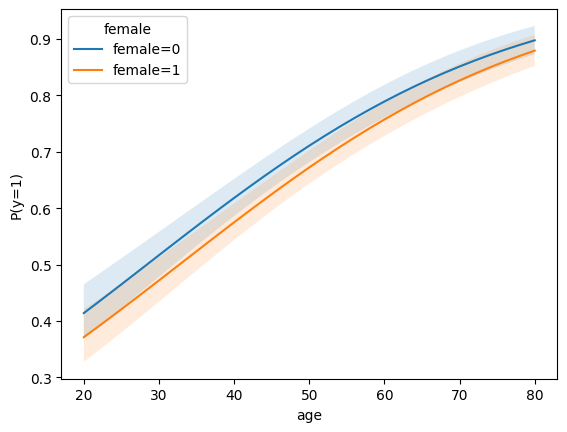

In [4]:
import matplotlib.pyplot as plt

ages = list(range(20, 81, 2))
res = m.predict(atexog={"age": ages, "female": [0, 1]})
df = res.to_frame()

fig, ax = plt.subplots()
for level, sub in df.groupby("female"):
    ax.plot(sub["age"], sub["estimate"], label=f"female={level}")
    ax.fill_between(sub["age"], sub["ci_lower"], sub["ci_upper"], alpha=0.15)
ax.set(xlabel="age", ylabel="P(y=1)")
ax.legend(title="female");

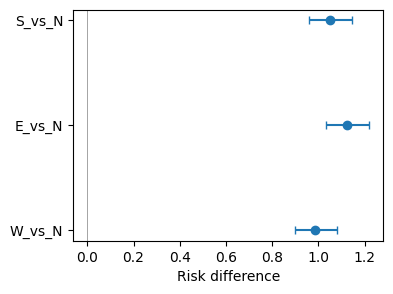

In [5]:
from pymargins import reference

scen, W = reference("region", ["N", "S", "E", "W"], ref_level="N")
res = m.contrasts(scenarios=scen, contrasts=W)
df = res.to_frame()

fig, ax = plt.subplots(figsize=(4, 3))
y = range(len(df))
ax.errorbar(
    df["estimate"],
    y,
    xerr=[df["estimate"] - df["ci_lower"], df["ci_upper"] - df["estimate"]],
    fmt="o",
    capsize=3,
)
ax.axvline(0, color="grey", lw=0.5)
ax.set_yticks(list(y))
ax.set_yticklabels(df["label"])
ax.set_xlabel("Risk difference")
ax.invert_yaxis()